# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



#Updated Code

In [ ]:
corpus = """
Deep learning is transforming artificial intelligence.
Machine learning enables systems to learn from data.
Artificial intelligence is changing the future of technology.
Neural networks are powerful tools for pattern recognition.
Deep learning models can generate meaningful sentences.
Recurrent neural networks process sequential information.
LSTM networks help remember long term dependencies.
GRU networks provide efficient memory mechanisms.
Text generation models predict the next word in a sequence.
Natural language processing enables communication between humans and machines.
Deep learning techniques are widely used in computer vision.
Machine learning algorithms improve with experience and data.
Artificial intelligence powers modern applications and services.
Language models learn grammar context and sentence structure.
Sequence models are important for text generation tasks.
"""
print(corpus)


Deep learning is transforming artificial intelligence.
Machine learning enables systems to learn from data.
Artificial intelligence is changing the future of technology.
Neural networks are powerful tools for pattern recognition.
Deep learning models can generate meaningful sentences.
Recurrent neural networks process sequential information.
LSTM networks help remember long term dependencies.
GRU networks provide efficient memory mechanisms.
Text generation models predict the next word in a sequence.
Natural language processing enables communication between humans and machines.
Deep learning techniques are widely used in computer vision.
Machine learning algorithms improve with experience and data.
Artificial intelligence powers modern applications and services.
Language models learn grammar context and sentence structure.
Sequence models are important for text generation tasks.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 82
X shape: (100, 9)
y shape: (100,)


#Udated Code

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
input_sequences.append(n_gram_sequence)
max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
          input_sequences,
          maxlen=max_len,
          padding='pre'
        )

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)



Vocabulary Size: 82
X Shape: (1, 7)
y Shape: (1,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


#Updated Code

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("✅ RNN Training Completed")

✅ RNN Training Completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


#Updated Code

In [ ]:

lstm_model = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("✅ LSTM Training Completed")

✅ LSTM Training Completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


#Updated Code

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("✅ GRU Training Completed")

✅ GRU Training Completed


## 📉 Compare Training Loss

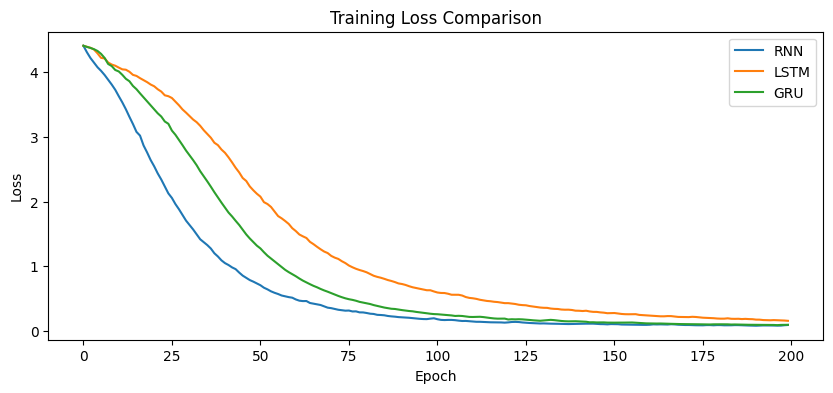

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

#Updated Code


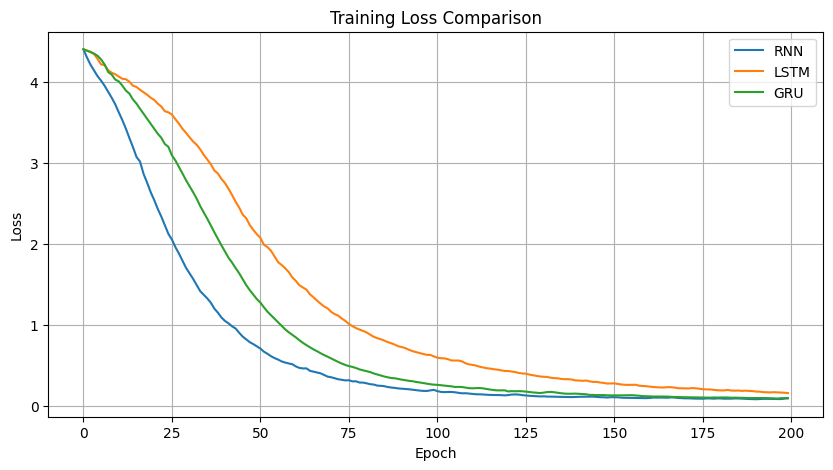

In [ ]:

plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

 # 📈 ACCURACY COMPARISON

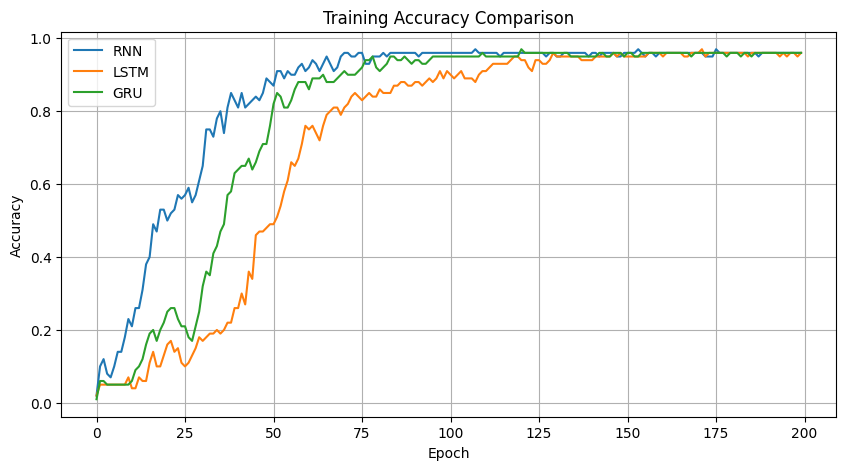

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

#Updated Code

In [ ]:

def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence powers
LSTM: deep learning intelligence and computer vision vision
GRU : deep learning techniques are widely in sequence


#Updated Code

In [ ]:
print("\nGenerated Text Samples\n")

print("RNN :")
print(generate_text(
    rnn_model,
    "deep learning",
    next_words=10
))

print("\nLSTM :")
print(generate_text(
    lstm_model,
    "deep learning",
    next_words=10
))

print("\nGRU :")
print(generate_text(
    gru_model,
    "deep learning",
    next_words=10
))


Generated Text Samples

RNN :
deep learning is transforming artificial intelligence powers modern applications and services and

LSTM :
deep learning intelligence and computer vision vision vision vision vision a vision

GRU :
deep learning techniques are widely in sequence sequence sequence sequence sequence mechanisms


# 📊 FINAL ACCURACY


In [ ]:

print("\nFinal Training Accuracy")

print("RNN Accuracy  :", round(
    rnn_history.history['accuracy'][-1]*100,2
), "%")

print("LSTM Accuracy :", round(
    lstm_history.history['accuracy'][-1]*100,2
), "%")

print("GRU Accuracy  :", round(
    gru_history.history['accuracy'][-1]*100,2
), "%")



Final Training Accuracy
RNN Accuracy  : 96.0 %
LSTM Accuracy : 96.0 %
GRU Accuracy  : 96.0 %


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**


**• Vanilla RNN learns short patterns but struggles
  with long-term dependencies.**

**• LSTM captures long-range contextual information
  using memory cells and gating mechanisms.**

**• GRU provides performance similar to LSTM with
  fewer parameters and faster computation.**

**• Sequence models are widely used in:
    - Chatbots
    - Machine Translation
    - Text Generation
    - Speech Recognition
    - Language Modeling**

**• This project demonstrates the practical
  implementation of sequence modeling using
  RNN, LSTM, and GRU architectures.**
